# Darija Vocabulary Build

Builds a word-frequency vocabulary (unigrams + bigrams) from the **full** cleaned corpus (both sources, all `data/processed/batch_*.jsonl` files — not the 1,000-doc reservoir sample used in `01_sample_and_explore.ipynb`). Output is a reusable artifact (`Data/vocab_unigrams.csv`, `Data/vocab_bigrams.csv`) for later dialect/script-related work — no MSA comparison or filtering happens here, this is the raw frequency foundation only.

## 1. Setup

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

# matplotlib's default font (DejaVu Sans) has no Arabic glyphs at all -- chart
# labels would render as tofu boxes without this. "Segoe UI" ships with
# Windows and covers Arabic script.
plt.rcParams["font.family"] = ["Segoe UI", "Tahoma", "Arial", "DejaVu Sans"]

try:
    import arabic_reshaper
    from bidi.algorithm import get_display

    def display_ar(text):
        """Reshape + bidi-reorder text for correct rendering in matplotlib,
        which doesn't apply Arabic shaping/bidi itself -- without this,
        Arabic chart labels show up as disconnected, reversed glyphs."""
        return get_display(arabic_reshaper.reshape(text))
except ImportError:
    def display_ar(text):
        return text

ROOT = Path.cwd().parent  # Notebooks/ -> Darija/
DATA_DIR = ROOT / "Data"

SOURCES = {
    "youtube": sorted((ROOT / "Youtube_scrap" / "data" / "processed").glob("batch_*.jsonl")),
    "djelfa_info": sorted((ROOT / "Mountada_djelfa_scrap" / "data" / "processed").glob("batch_*.jsonl")),
}
for name, files in SOURCES.items():
    if not files:
        raise FileNotFoundError(f"no processed batch files found for {name}")
    print(f"{name}: {[f.name for f in files]}")

youtube: ['batch_2026-08-08.jsonl']
djelfa_info: ['batch_2026-08-08.jsonl']


### Tokenizer

Simple regex tokenizer, no library dependency (matches the project's existing "no heavyweight tokenizer" stance). Lowercases first (no-op on Arabic, normalizes Latin/Arabizi/French case), then splits on `\w+` — this correctly keeps Arabizi tokens like `"3andi"` intact (digit glued to letters, no boundary) while still separating real numbers as their own tokens. Purely-numeric tokens and the two known anonymization placeholders (`[URL]`/`[MENTION]`, which survive as bare `url`/`mention` words since brackets aren't `\w` characters) are dropped afterward.

Known simplification: bigrams can span an original newline/paragraph break, since `\w+` doesn't treat newlines specially. Fine for a v1 vocabulary — not engineered around.

In [2]:
TOKEN_RE = re.compile(r"\w+", re.UNICODE)
_PLACEHOLDER_TOKENS = {"url", "mention"}


def tokenize(text):
    tokens = TOKEN_RE.findall(text.lower())
    return [t for t in tokens if not t.isdigit() and t not in _PLACEHOLDER_TOKENS]


# quick smoke test
print(tokenize("Wach rakoum 3andi 1500 دج و [URL] [MENTION] هههه"))

['wach', 'rakoum', '3andi', 'دج', 'و', 'هههه']


## 2. Stream the full corpus and count

One pass per source. Tracks total count, per-source count, and document frequency (via `set(tokens)`/`set(bigrams)` per doc) for both unigrams and bigrams.

In [3]:
unigram_counts = {name: Counter() for name in SOURCES}
unigram_doc_counts = {name: Counter() for name in SOURCES}
bigram_counts = {name: Counter() for name in SOURCES}
bigram_doc_counts = {name: Counter() for name in SOURCES}
doc_totals = {name: 0 for name in SOURCES}

for name, files in SOURCES.items():
    for path in files:
        with path.open("r", encoding="utf-8") as f:
            for line in tqdm(f, desc=f"{name}:{path.name}"):
                line = line.strip()
                if not line:
                    continue
                doc = json.loads(line)
                tokens = tokenize(doc["text"])
                if not tokens:
                    continue
                doc_totals[name] += 1
                unigram_counts[name].update(tokens)
                unigram_doc_counts[name].update(set(tokens))
                bigrams = list(zip(tokens, tokens[1:]))
                if bigrams:
                    bigram_counts[name].update(bigrams)
                    bigram_doc_counts[name].update(set(bigrams))

for name in SOURCES:
    print(f"{name}: {doc_totals[name]:,} docs, {sum(unigram_counts[name].values()):,} token occurrences")

youtube:batch_2026-08-08.jsonl: 0it [00:00, ?it/s]

djelfa_info:batch_2026-08-08.jsonl: 0it [00:00, ?it/s]

youtube: 1,040,138 docs, 10,488,024 token occurrences
djelfa_info: 124,911 docs, 12,843,293 token occurrences


## 3. Combine into vocabulary tables

In [4]:
all_unigrams = set(unigram_counts["youtube"]) | set(unigram_counts["djelfa_info"])

rows = []
for tok in all_unigrams:
    yt = unigram_counts["youtube"].get(tok, 0)
    dj = unigram_counts["djelfa_info"].get(tok, 0)
    doc = unigram_doc_counts["youtube"].get(tok, 0) + unigram_doc_counts["djelfa_info"].get(tok, 0)
    rows.append((tok, yt + dj, yt, dj, doc))

unigram_df = pd.DataFrame(rows, columns=["token", "total_count", "youtube_count", "djelfa_count", "doc_count"])
unigram_df = unigram_df.sort_values("total_count", ascending=False).reset_index(drop=True)
print(f"unique unigrams: {len(unigram_df):,}")
unigram_df.head(20)

unique unigrams: 955,260


,token,total_count,youtube_count,djelfa_count,doc_count
0,في,475424,171148,304276,184320
1,من,443420,136495,306925,162456
2,الله,433355,149166,284189,176102
3,و,384189,195364,188825,141114
4,على,248301,90537,157764,121716
5,لا,137843,36352,101491,60154
6,ما,137279,47549,89730,67305
7,أن,123848,7817,116031,32622
8,ربي,98511,88182,10329,86163
9,عليه,89567,15983,73584,30561


In [5]:
all_bigrams = set(bigram_counts["youtube"]) | set(bigram_counts["djelfa_info"])

rows = []
for bg in all_bigrams:
    yt = bigram_counts["youtube"].get(bg, 0)
    dj = bigram_counts["djelfa_info"].get(bg, 0)
    doc = bigram_doc_counts["youtube"].get(bg, 0) + bigram_doc_counts["djelfa_info"].get(bg, 0)
    rows.append((f"{bg[0]} {bg[1]}", yt + dj, yt, dj, doc))

bigram_df = pd.DataFrame(rows, columns=["bigram", "total_count", "youtube_count", "djelfa_count", "doc_count"])
bigram_df = bigram_df.sort_values("total_count", ascending=False).reset_index(drop=True)
print(f"unique bigrams: {len(bigram_df):,}")
bigram_df.head(20)

unique bigrams: 9,184,948


,bigram,total_count,youtube_count,djelfa_count,doc_count
0,الله عليه,49020,4152,44868,13896
1,صلى الله,46828,3498,43330,12759
2,عليه وسلم,43110,2650,40460,11383
3,شاء الله,33806,21766,12040,30495
4,السلام عليكم,29082,3247,25835,27496
5,رسول الله,23651,1938,21713,8576
6,بارك الله,22027,9236,12791,20598
7,ان شاء,19838,13184,6654,18403
8,الله فيك,19708,9130,10578,18820
9,الله تعالى,17085,1169,15916,8270


## 4. Save outputs

Full vocabulary, not just top-N — kept complete/neutral (no stopword filtering or minimum-frequency pruning), since downstream use decides what to filter.

In [6]:
unigram_path = DATA_DIR / "vocab_unigrams.csv"
bigram_path = DATA_DIR / "vocab_bigrams.csv"

unigram_df.to_csv(unigram_path, index=False, encoding="utf-8")
bigram_df.to_csv(bigram_path, index=False, encoding="utf-8")

print(f"saved {len(unigram_df):,} unigrams -> {unigram_path}")
print(f"saved {len(bigram_df):,} bigrams -> {bigram_path}")

saved 955,260 unigrams -> C:\Users\ASUS\Desktop\summer 2026\Darija\Data\vocab_unigrams.csv
saved 9,184,948 bigrams -> C:\Users\ASUS\Desktop\summer 2026\Darija\Data\vocab_bigrams.csv


## 5. Sanity checks

In [7]:
total_tokens = sum(sum(c.values()) for c in unigram_counts.values())
print(f"total token occurrences (combined): {total_tokens:,}")
print(f"unique unigrams: {len(unigram_df):,}")
print(f"unique bigrams: {len(bigram_df):,}")
print()
for name in SOURCES:
    print(f"{name}: {doc_totals[name]:,} docs, {sum(unigram_counts[name].values()):,} tokens, "
          f"{len(unigram_counts[name]):,} unique unigrams, {len(bigram_counts[name]):,} unique bigrams")

total token occurrences (combined): 23,331,317
unique unigrams: 955,260
unique bigrams: 9,184,948

youtube: 1,040,138 docs, 10,488,024 tokens, 641,476 unique unigrams, 4,751,836 unique bigrams
djelfa_info: 124,911 docs, 12,843,293 tokens, 480,285 unique unigrams, 4,846,786 unique bigrams


In [8]:
print("--- top 50 unigrams ---")
print(unigram_df.head(50).to_string(index=False))
print()
print("--- top 30 bigrams ---")
print(bigram_df.head(30).to_string(index=False))

--- top 50 unigrams ---
 token  total_count  youtube_count  djelfa_count  doc_count
    في       475424         171148        304276     184320
    من       443420         136495        306925     162456
  الله       433355         149166        284189     176102
     و       384189         195364        188825     141114
   على       248301          90537        157764     121716
    لا       137843          36352        101491      60154
    ما       137279          47549         89730      67305
    أن       123848           7817        116031      32622
   ربي        98511          88182         10329      86163
  عليه        89567          15983         73584      30561
    لي        89511          72307         17204      71821
    عن        86436           9318         77118      32449
   انا        85585          73717         11868      73311
   هذا        82865          27564         55301      47436
    كل        76916          33670         43246      53132
   ولا        74

In [9]:
# The 9 example Darija function words from Project_context.md's Phase 1 plan --
# confirms the corpus/tokenizer behave sensibly, and gives them a first real
# frequency anchor (currently just an unweighted example list).
KNOWN_DARIJA_WORDS = ["wach", "kayen", "bezzaf", "raki", "chkoun", "khoya", "wallah", "hna", "kima"]

rank_by_token = {tok: i + 1 for i, tok in enumerate(unigram_df["token"])}
for w in KNOWN_DARIJA_WORDS:
    row = unigram_df[unigram_df["token"] == w]
    if row.empty:
        print(f"{w}: NOT FOUND in vocabulary")
        continue
    r = row.iloc[0]
    print(f"{w}: rank {rank_by_token[w]:,}, total_count={r['total_count']:,}, "
          f"youtube={r['youtube_count']:,}, djelfa={r['djelfa_count']:,}")

wach: rank 3,059, total_count=876, youtube=847, djelfa=29
kayen: rank 5,980, total_count=430, youtube=421, djelfa=9


bezzaf: rank 17,354, total_count=129, youtube=125, djelfa=4
raki: rank 8,209, total_count=306, youtube=301, djelfa=5
chkoun: rank 8,364, total_count=300, youtube=296, djelfa=4


khoya: rank 1,969, total_count=1,363, youtube=1,335, djelfa=28
wallah: rank 6,459, total_count=394, youtube=387, djelfa=7
hna: rank 2,388, total_count=1,136, youtube=1,115, djelfa=21


kima: rank 1,524, total_count=1,726, youtube=1,705, djelfa=21


In [10]:
cum_pct = unigram_df["total_count"].cumsum() / unigram_df["total_count"].sum()
n50 = int((cum_pct >= 0.5).idxmax()) + 1
n90 = int((cum_pct >= 0.9).idxmax()) + 1
print(f"unique tokens needed for 50% coverage: {n50:,} / {len(unigram_df):,} unique types")
print(f"unique tokens needed for 90% coverage: {n90:,} / {len(unigram_df):,} unique types")

unique tokens needed for 50% coverage: 1,357 / 955,260 unique types
unique tokens needed for 90% coverage: 75,652 / 955,260 unique types


## 6. Vocabulary statistics and visualizations

Deeper look at the shape of the vocabulary itself — long-tail size, script
composition, source overlap — beyond the pass/fail sanity checks above.

### 6a. Long-tail / distribution stats

Hapax legomena (tokens seen exactly once) are the classic noise signal in a
corpus-derived vocabulary — typos, rare proper nouns, one-off Arabizi
spellings. A high hapax rate is expected and not itself a problem, but
worth knowing before treating the full 955K-token vocabulary as "clean."

In [11]:
hapax = (unigram_df["total_count"] == 1).sum()
print(f"hapax legomena (count == 1): {hapax:,} ({hapax / len(unigram_df) * 100:.1f}% of unique unigrams)")
print(f"tokens with count <= 5: {(unigram_df['total_count'] <= 5).sum():,} "
      f"({(unigram_df['total_count'] <= 5).mean() * 100:.1f}%)")
print()
print("total_count distribution:")
print(unigram_df["total_count"].describe())
print()
token_lengths = unigram_df["token"].str.len()
print("token character-length distribution (unique types, unweighted):")
print(token_lengths.describe())

hapax legomena (count == 1): 516,032 (54.0% of unique unigrams)
tokens with count <= 5: 773,716 (81.0%)

total_count distribution:
count    955260.000000
mean         24.424049
std        1062.883676
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max      475424.000000
Name: total_count, dtype: float64



token character-length distribution (unique types, unweighted):
count    955260.000000
mean          6.556591
std           3.822795
min           1.000000
25%           5.000000
50%           6.000000
75%           7.000000
max        1138.000000
Name: token, dtype: float64


### 6b. Zipf plot (rank vs. frequency)

A roughly straight line on a log-log plot is the expected signature of
natural-language text (Zipf's law) — a sanity check on the corpus/tokenizer
at a glance, distinct from the targeted checks in Section 5.

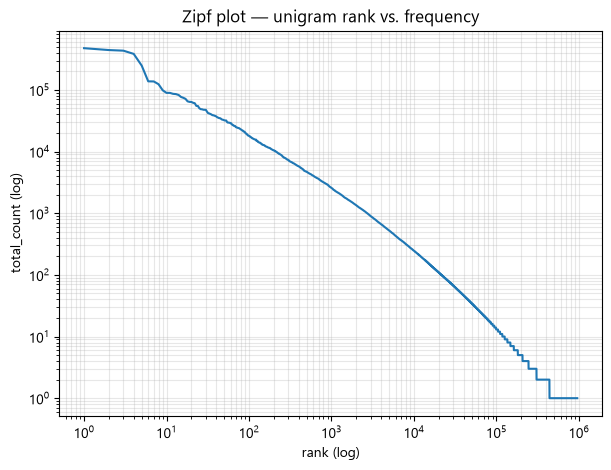

In [12]:
ranks = range(1, len(unigram_df) + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, unigram_df["total_count"])
ax.set_xlabel("rank (log)")
ax.set_ylabel("total_count (log)")
ax.set_title("Zipf plot — unigram rank vs. frequency")
ax.grid(True, which="both", alpha=0.3)
plt.show()

### 6c. Cumulative coverage curve

Visual version of Section 5's 50%/90% coverage numbers — how much of the
corpus's token *occurrences* a given vocabulary *size* actually covers.

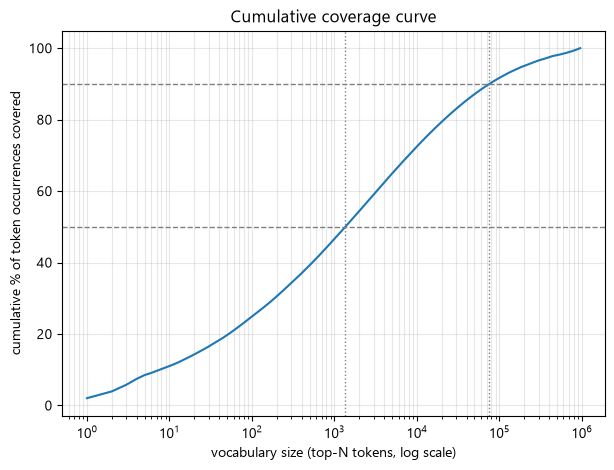

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ranks, cum_pct * 100)
ax.set_xscale("log")
ax.set_xlabel("vocabulary size (top-N tokens, log scale)")
ax.set_ylabel("cumulative % of token occurrences covered")
ax.set_title("Cumulative coverage curve")
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
ax.axhline(90, color="gray", linestyle="--", linewidth=1)
ax.axvline(n50, color="gray", linestyle=":", linewidth=1)
ax.axvline(n90, color="gray", linestyle=":", linewidth=1)
ax.grid(True, which="both", alpha=0.3)
plt.show()

### 6d. Token length distribution

Unusually many very short (1-char) or very long (20+ char) tokens would
suggest tokenizer noise (stray characters, unsplit run-on text) rather than
real words.

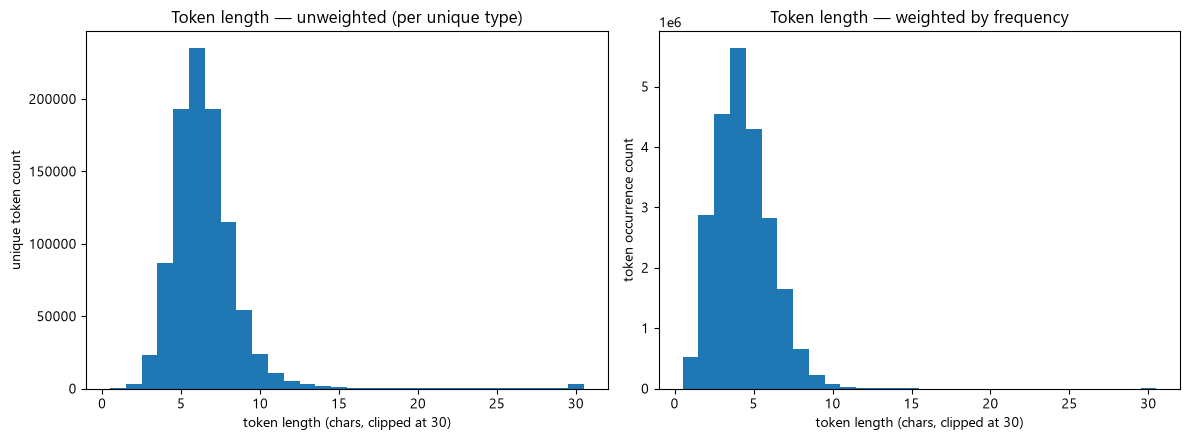

unique tokens of length 1: 402
unique tokens of length >= 20: 4,830


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

max_len = min(int(token_lengths.max()), 30)
axes[0].hist(token_lengths.clip(upper=max_len), bins=range(1, max_len + 2), align="left")
axes[0].set_xlabel("token length (chars, clipped at 30)")
axes[0].set_ylabel("unique token count")
axes[0].set_title("Token length — unweighted (per unique type)")

axes[1].hist(
    token_lengths.clip(upper=max_len),
    bins=range(1, max_len + 2),
    align="left",
    weights=unigram_df["total_count"],
)
axes[1].set_xlabel("token length (chars, clipped at 30)")
axes[1].set_ylabel("token occurrence count")
axes[1].set_title("Token length — weighted by frequency")

plt.tight_layout()
plt.show()

print(f"unique tokens of length 1: {(token_lengths == 1).sum():,}")
print(f"unique tokens of length >= 20: {(token_lengths >= 20).sum():,}")

### 6e. Script composition of the vocabulary

Buckets each unique token as Arabic-script, Latin-script (Arabizi/French/
English), mixed, or other, by Unicode block — a first look at the
Arabic/Latin split this vocabulary will eventually feed into script
detection. Shown both by unique-type count and by frequency-weighted
occurrence count, since a small number of very common tokens can dominate
the weighted view differently from the unweighted one.

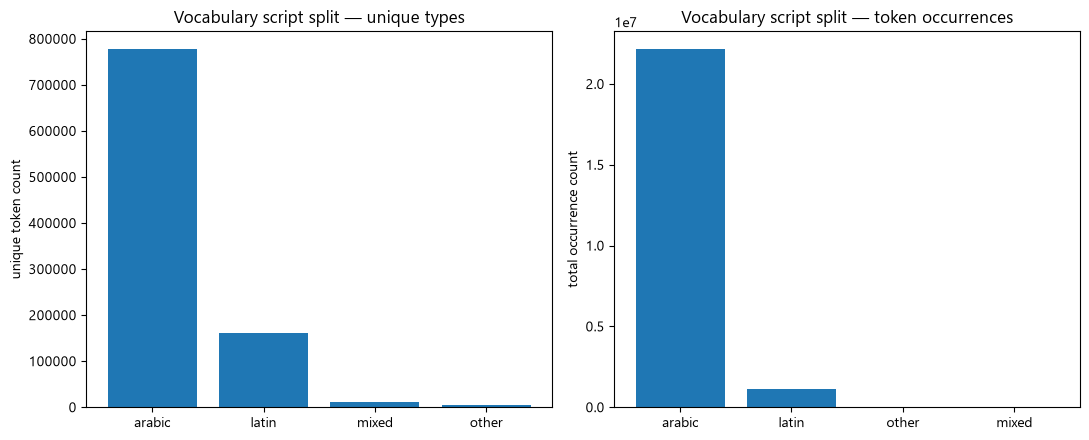

by unique type:
 script
arabic    777430
latin     161396
mixed      11392
other       5042
Name: count, dtype: int64 

by occurrence:
 script
arabic    22150697
latin      1145144
other        22870
mixed        12606
Name: total_count, dtype: int64

sample 'other' tokens (neither Arabic nor Latin letters):
['_', 'à', 'ﷺ', 'ï', '¾', 'â', 'ㅤ', 'ﻻ', 'ღ', '__', '1_', 'ﻣﻦ', '2_', '___', '½ï', '___________________________________', '____', 'ﻓﻲ', 'ㅤㅤ', 'ﷲ']


In [15]:
_ARABIC_RE = re.compile(r"[؀-ۿ]")  # same block used by clean_text.py elsewhere in this project
_LATIN_RE = re.compile(r"[a-zA-Z]")


def classify_script(token):
    has_ar = bool(_ARABIC_RE.search(token))
    has_lat = bool(_LATIN_RE.search(token))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


unigram_df["script"] = unigram_df["token"].apply(classify_script)

by_type = unigram_df["script"].value_counts()
by_occurrence = unigram_df.groupby("script")["total_count"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(by_type.index, by_type.values)
axes[0].set_title("Vocabulary script split — unique types")
axes[0].set_ylabel("unique token count")

axes[1].bar(by_occurrence.index, by_occurrence.values)
axes[1].set_title("Vocabulary script split — token occurrences")
axes[1].set_ylabel("total occurrence count")

plt.tight_layout()
plt.show()

print("by unique type:\n", by_type, "\n")
print("by occurrence:\n", by_occurrence)
print("\nsample 'other' tokens (neither Arabic nor Latin letters):")
print(unigram_df[unigram_df["script"] == "other"]["token"].head(20).tolist())

### 6f. Source overlap (YouTube-only / djelfa-only / shared)

Most unique *types* are likely single-source (rare/dialectal/typo tokens
concentrated in one corpus), while a small number of *shared* high-frequency
words probably account for most token *occurrences* — the two panels below
should look quite different from each other if so.

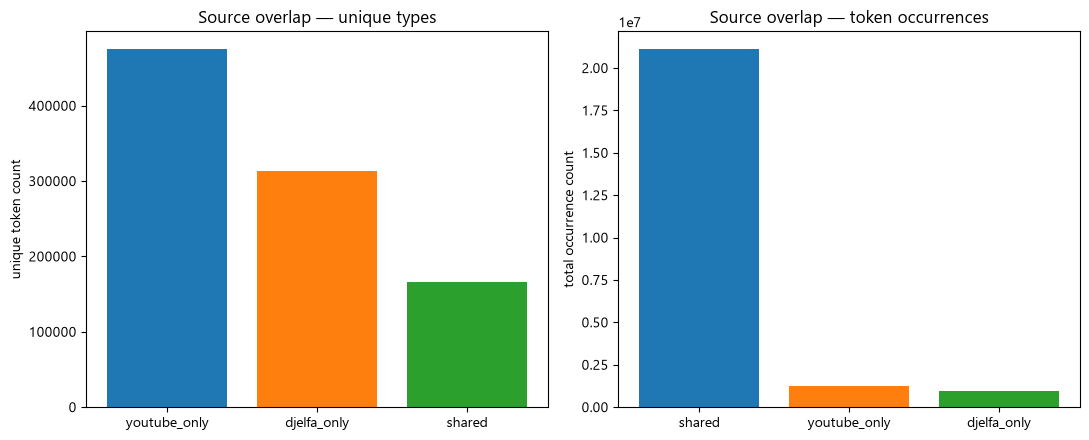

by unique type:
 overlap
youtube_only    474975
djelfa_only     313784
shared          166501
Name: count, dtype: int64 

by occurrence:
 overlap
shared          21109904
youtube_only     1272087
djelfa_only       949326
Name: total_count, dtype: int64


In [16]:
def classify_overlap(row):
    if row["youtube_count"] > 0 and row["djelfa_count"] > 0:
        return "shared"
    if row["youtube_count"] > 0:
        return "youtube_only"
    return "djelfa_only"


unigram_df["overlap"] = unigram_df.apply(classify_overlap, axis=1)

overlap_by_type = unigram_df["overlap"].value_counts()
overlap_by_occurrence = unigram_df.groupby("overlap")["total_count"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(overlap_by_type.index, overlap_by_type.values, color=["tab:blue", "tab:orange", "tab:green"])
axes[0].set_title("Source overlap — unique types")
axes[0].set_ylabel("unique token count")

axes[1].bar(overlap_by_occurrence.index, overlap_by_occurrence.values, color=["tab:blue", "tab:orange", "tab:green"])
axes[1].set_title("Source overlap — token occurrences")
axes[1].set_ylabel("total occurrence count")

plt.tight_layout()
plt.show()

print("by unique type:\n", overlap_by_type, "\n")
print("by occurrence:\n", overlap_by_occurrence)

### 6g. Top-20 unigrams and bigrams (bar charts)

Visual complement to the printed tables in Section 5.

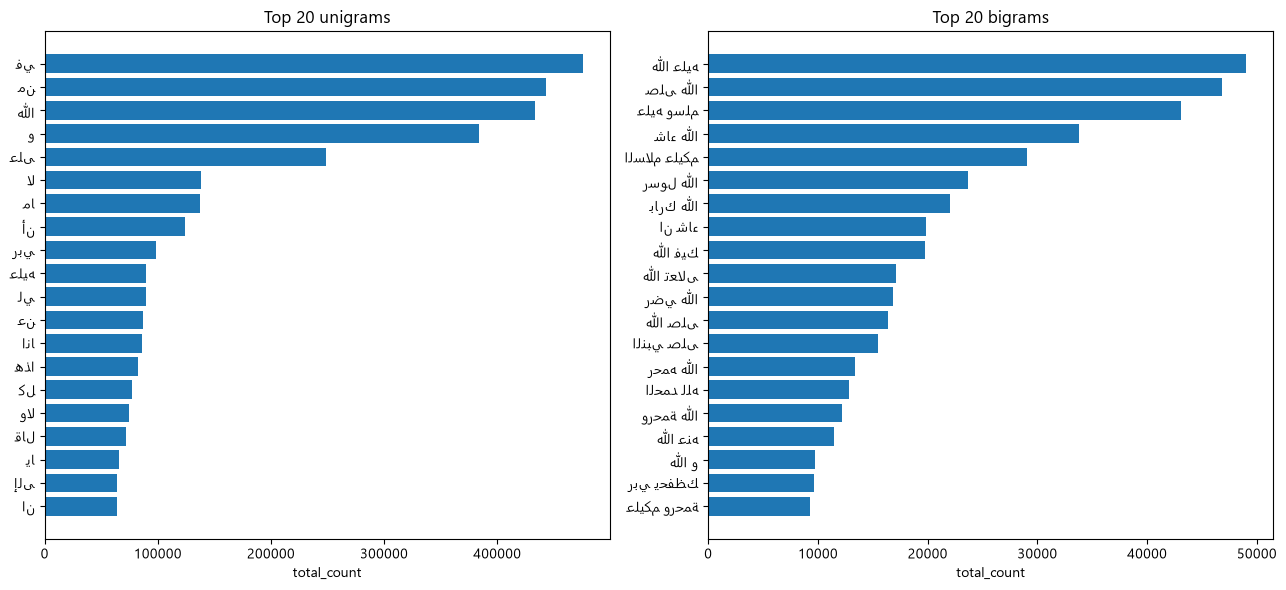

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_uni = unigram_df.head(20).iloc[::-1]
axes[0].barh([display_ar(t) for t in top_uni["token"]], top_uni["total_count"])
axes[0].set_title("Top 20 unigrams")
axes[0].set_xlabel("total_count")

top_bi = bigram_df.head(20).iloc[::-1]
axes[1].barh([display_ar(t) for t in top_bi["bigram"]], top_bi["total_count"])
axes[1].set_title("Top 20 bigrams")
axes[1].set_xlabel("total_count")

plt.tight_layout()
plt.show()